<a href="https://colab.research.google.com/github/christianpm-hub/Teachable-Machine/blob/main/Teachable_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TEACHABLE MACHINE DE TECLADO Y RATÓN**

1. Objetivo

El objetivo del proyecto es crear un sistema de inteligencia artificial capaz de reconocer mediante la cámara si el objeto que aparece es un teclado o un ratón.

Para ello se ha utilizado Teachable Machine para crear y entrenar el modelo, y posteriormente se ha integrado en una página web mediante HTML y JavaScript.

2. Creación del modelo

Primero se creó un proyecto de reconocimiento de imágenes en Teachable Machine.

Se crearon dos clases:

Teclado

Ratón

Después se añadieron diferentes imágenes de cada objeto para que el modelo pudiera aprender a diferenciarlos.
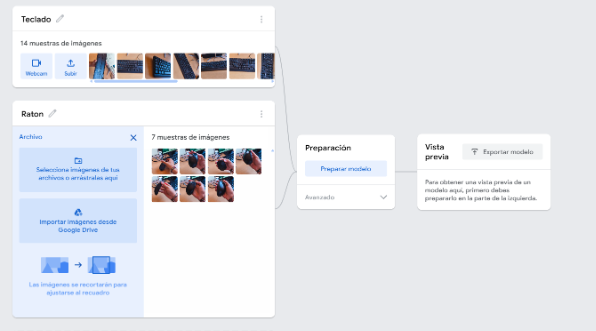

3. Entrenamiento

Una vez añadidas las imágenes, se entrenó el modelo.

Durante el entrenamiento, Teachable Machine analiza las imágenes proporcionadas y aprende las características de cada objeto.

Después se realizaron varias pruebas para comprobar que el modelo reconocía correctamente tanto el teclado como el ratón.

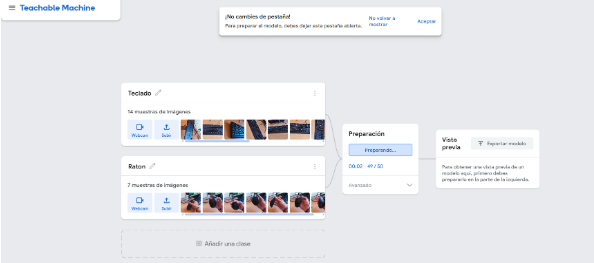

4. Exportación

Cuando el modelo funcionó correctamente, se exportó en un formato compatible con páginas web.

De esta manera, el modelo podía utilizarse posteriormente desde un archivo HTML.

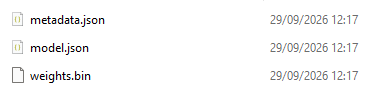

5. Implementación en HTML

Una vez exportado el modelo, se integró en una página web.

La página utiliza la cámara del ordenador para obtener imágenes en tiempo real y enviarlas al modelo para realizar la predicción.

El resultado se muestra directamente en la página.

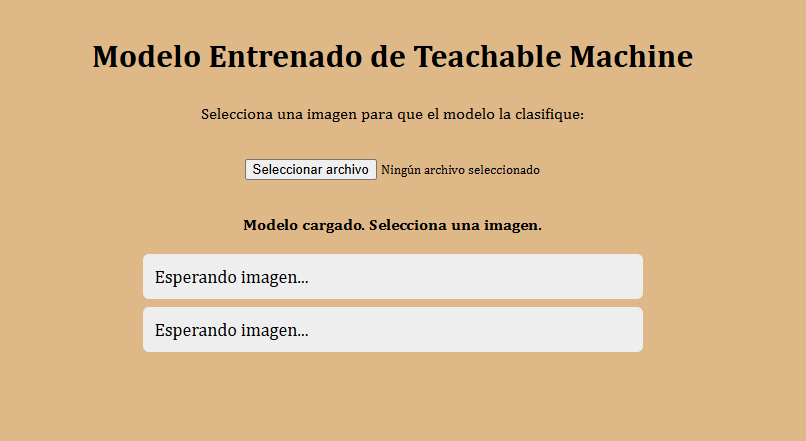



6. Sistema de reconocimiento

Se estableció un 90 % de confianza como mínimo para considerar que un objeto ha sido reconocido.

El funcionamiento es:

Si Teclado ≥ 90 % → se reconoce como Teclado.

Si Ratón ≥ 90 % → se reconoce como Ratón.

Si ninguno supera el 90 % → aparece “No es ninguno de esos objetos”.

Por ejemplo, si el modelo obtiene un 95 % para teclado, se mostrará que es un teclado. Si obtiene un 60 % para teclado y un 40 % para ratón, no se reconocerá ninguno.

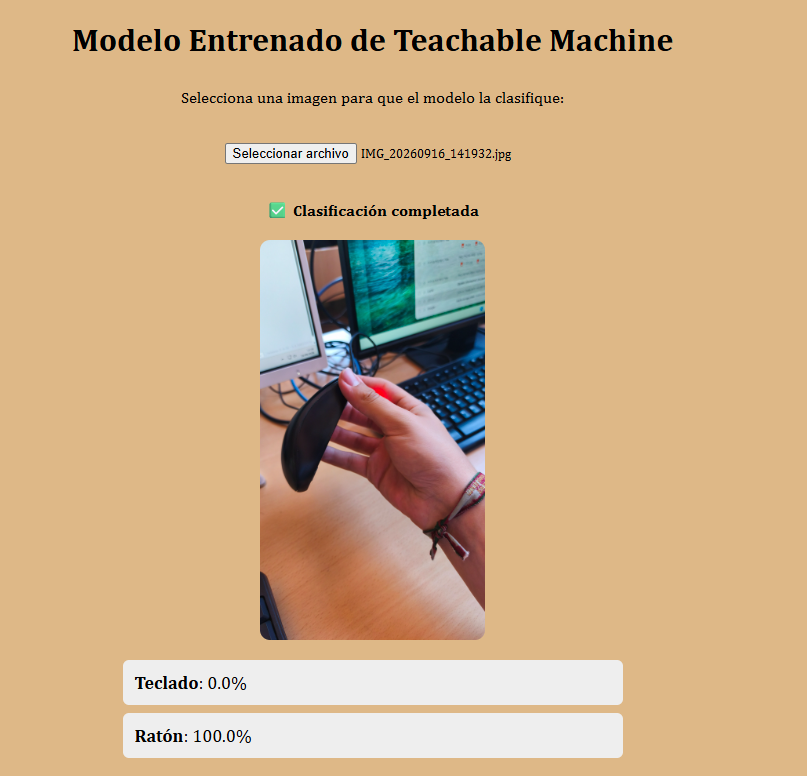

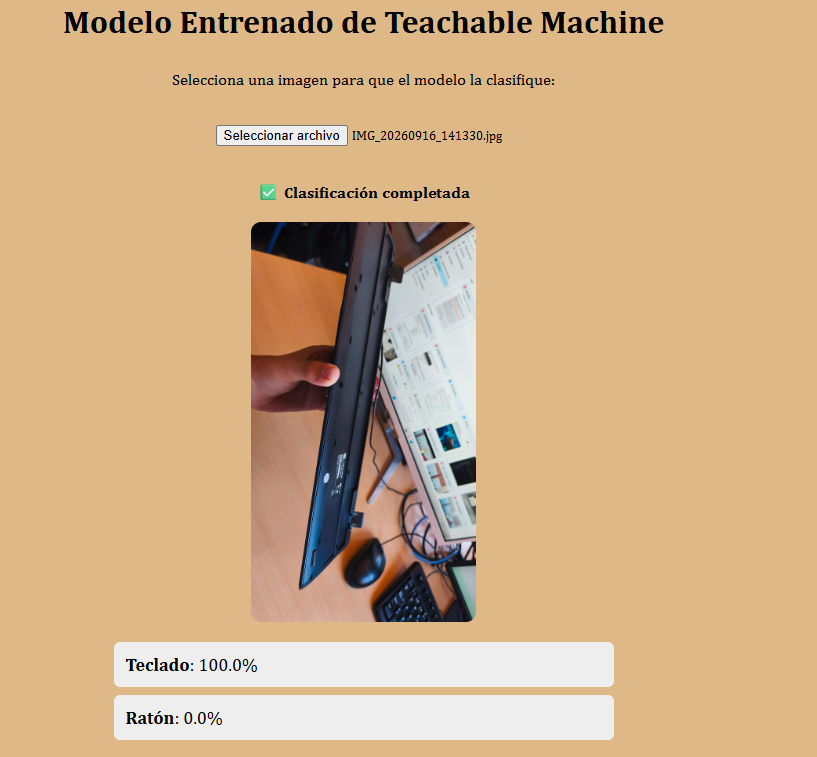

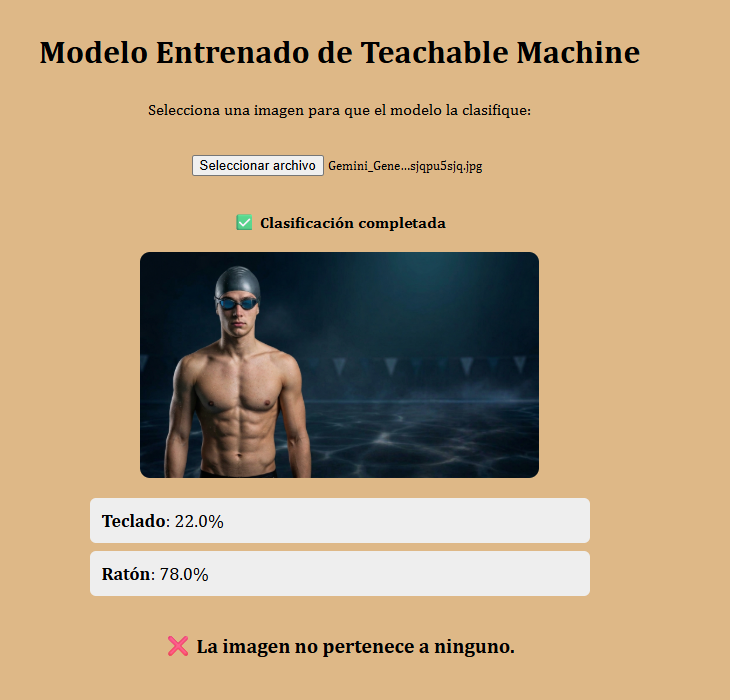





7. Resultado final

El resultado final es una página web capaz de utilizar la cámara para reconocer en tiempo real un teclado o un ratón.

El uso del límite del 90 % permite evitar que el sistema clasifique como teclado o ratón objetos que no pertenecen a ninguna de las dos clases.

8. Conclusión

Con este proyecto se ha aprendido a crear y entrenar un modelo de inteligencia artificial con Teachable Machine y posteriormente integrarlo en una página web para realizar reconocimiento de objetos en tiempo real.

Código:

<!DOCTYPE html>
<html lang="es">

<style>
    *{
        font-family: Cambria, Cochin, Georgia, Times, 'Times New Roman', serif;
    }

    body{
        background-color: burlywood;
    }
</style>

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Clasificador de imágenes</title>

    <style>

        body {
            font-family: Arial, sans-serif;
            text-align: center;
            padding: 30px;
        }

        h1 {
            margin-bottom: 30px;
        }

        #imageUpload {
            margin: 20px;
        }

        #preview {
            display: none;

            max-width: 400px;
            max-height: 400px;

            margin: 20px auto;

            border-radius: 10px;
        }

        #label-container {
            width: 500px;
            max-width: 90%;

            margin: 20px auto;
        }

        .resultado {
            background: #eeeeee;

            padding: 12px;

            margin: 8px 0;

            border-radius: 6px;

            text-align: left;

            font-size: 18px;
        }

        #estado {
            margin: 15px;

            font-weight: bold;
        }

        /* MENSAJE DE RESULTADO */

        #mensaje-final {
            margin: 20px auto;

            padding: 15px;

            width: 500px;
            max-width: 90%;

            font-size: 20px;

            font-weight: bold;

            border-radius: 8px;
        }

    </style>

</head>


<body>

    <h1>Modelo Entrenado de Teachable Machine</h1>

    <p>
        Selecciona una imagen para que el modelo la clasifique:
    </p>


    <input
        type="file"
        id="imageUpload"
        accept="image/*"
    >


    <div id="estado">
        Cargando modelo...
    </div>


    <!-- Imagen seleccionada -->

    <img
        id="preview"
        alt="Imagen seleccionada"
    >


    <!-- Resultados -->

    <div id="label-container"></div>


    <!-- MENSAJE FINAL -->

    <div id="mensaje-final"></div>



    <!-- TensorFlow -->

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>


    <!-- Teachable Machine -->

    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>



    <script>

        // =====================================================
        // CARPETA DEL MODELO
        // =====================================================

        const MODEL_URL = "./modelo/";


        let model;

        let maxPredictions;



        // =====================================================
        // CARGAR MODELO
        // =====================================================

        async function init() {

            try {

                console.log("Cargando modelo...");

                const modelURL =
                    MODEL_URL + "model.json";

                const metadataURL =
                    MODEL_URL + "metadata.json";


                model = await tmImage.load(
                    modelURL,
                    metadataURL
                );


                console.log("Modelo cargado correctamente");


                maxPredictions =
                    model.getTotalClasses();


                // Crear espacios para los resultados

                const labelContainer =
                    document.getElementById(
                        "label-container"
                    );


                labelContainer.innerHTML = "";


                for (
                    let i = 0;
                    i < maxPredictions;
                    i++
                ) {

                    const div =
                        document.createElement("div");


                    div.className =
                        "resultado";


                    div.innerHTML =
                        "Esperando imagen...";


                    labelContainer.appendChild(div);

                }


                document.getElementById(
                    "estado"
                ).innerHTML =
                    "Modelo cargado. Selecciona una imagen.";


            }

            catch (error) {

                console.error(error);


                document.getElementById(
                    "estado"
                ).innerHTML =
                    "❌ Error al cargar el modelo.";


                alert(
                    "No se ha podido cargar el modelo.\n\n" +
                    "Comprueba que la carpeta 'modelo' contiene:\n" +
                    "- model.json\n" +
                    "- metadata.json\n" +
                    "- los archivos .bin"
                );

            }

        }



        // =====================================================
        // SELECCIONAR IMAGEN
        // =====================================================

        document
            .getElementById("imageUpload")
            .addEventListener(
                "change",
                function(event) {


                    const file =
                        event.target.files[0];


                    if (!file) {
                        return;
                    }


                    console.log(
                        "Imagen seleccionada:",
                        file.name
                    );


                    // Comprobar que es una imagen

                    if (
                        !file.type.startsWith("image/")
                    ) {

                        alert(
                            "El archivo seleccionado no es una imagen."
                        );

                        return;

                    }


                    const preview =
                        document.getElementById(
                            "preview"
                        );


                    const imageURL =
                        window.URL.createObjectURL(
                            file
                        );


                    preview.onload = async function() {

                        console.log(
                            "Imagen cargada correctamente"
                        );


                        preview.style.display =
                            "block";


                        if (!model) {

                            alert(
                                "El modelo todavía no se ha cargado."
                            );

                            return;

                        }


                        await predict(preview);

                    };


                    preview.onerror = function() {

                        console.error(
                            "No se pudo cargar la imagen."
                        );

                        alert(
                            "No se pudo cargar la imagen."
                        );

                    };


                    // Mostrar imagen

                    preview.src =
                        imageURL;


                }
            );



        // =====================================================
        // HACER PREDICCIÓN
        // =====================================================

        async function predict(image) {

            try {

                console.log(
                    "Analizando imagen..."
                );


                document.getElementById(
                    "estado"
                ).innerHTML =
                    "🔍 Analizando imagen...";


                // Limpiar mensaje anterior

                document.getElementById(
                    "mensaje-final"
                ).innerHTML = "";


                // Realizar predicción

                const prediction =
                    await model.predict(image);


                console.log(
                    "Predicción:",
                    prediction
                );


                const labelContainer =
                    document.getElementById(
                        "label-container"
                    );


                // Variables para saber
                // si es ratón o teclado

                let esRaton = false;

                let esTeclado = false;


                // Mostrar resultados

                for (
                    let i = 0;
                    i < maxPredictions;
                    i++
                ) {


                    const porcentaje =
                        (
                            prediction[i]
                                .probability * 100
                        ).toFixed(1);


                    const nombre =
                        prediction[i].className;


                    labelContainer
                        .childNodes[i]
                        .innerHTML =

                        "<strong>" +
                        nombre +
                        "</strong>: " +
                        porcentaje +
                        "%";


                    // =========================================
                    // COMPROBAR 90%
                    // =========================================

                    if (
                        nombre.toLowerCase().includes("raton") ||
                        nombre.toLowerCase().includes("ratón")
                    ) {

                        if (
                            prediction[i].probability >= 0.90
                        ) {

                            esRaton = true;

                        }

                    }


                    if (
                        nombre.toLowerCase().includes("teclado")
                    ) {

                        if (
                            prediction[i].probability >= 0.90
                        ) {

                            esTeclado = true;

                        }

                    }

                }


                // =====================================================
                // MOSTRAR MENSAJE FINAL
                // =====================================================

                const mensajeFinal =
                    document.getElementById(
                        "mensaje-final"
                    );


                if (esRaton) {

                    mensajeFinal.innerHTML =
                        "🖱️ La imagen pertenece a un RATÓN.";


                }
                else if (esTeclado) {

                    mensajeFinal.innerHTML =
                        "⌨️ La imagen pertenece a un TECLADO.";


                }
                else {

                    mensajeFinal.innerHTML =
                        "❌ La imagen no pertenece a ninguno.";


                }


                document.getElementById(
                    "estado"
                ).innerHTML =
                    "✅ Clasificación completada";


            }

            catch (error) {

                console.error(
                    "Error en la predicción:",
                    error
                );


                document.getElementById(
                    "estado"
                ).innerHTML =
                    "❌ Error al analizar la imagen";


                alert(
                    "Ha ocurrido un error al analizar la imagen."
                );

            }

        }


        // =====================================================
        // INICIAR
        // =====================================================

        init();

    </script>

</body>

</html>